In [1]:
# This file runs functions to find the number of people affected
# in buffers or oil and gas wells. 

In [1]:
import pathlib
import pandas as pd
import sys
import geopandas as gpd
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt

# Define base path
repo = pathlib.Path.cwd().parent

# Define data paths

# location of the oil and gas data
oil_path = pathlib.Path("/Users/ninaflores/Library/CloudStorage/OneDrive-SharedLibraries-UW/casey_cohort - Documents/data/environmental/oil_and_gas/raw_data/ogim.parquet")

# location of the adminstrative boundary shapefile
countries_path = pathlib.Path("/Users/ninaflores/Library/CloudStorage/OneDrive-SharedLibraries-UW/casey_cohort - Documents/data/geo_boundaries/processed_data/country_admin/country_geom_filtered.parquet")
#countries_path = pathlib.Path("/Users/ninaflores/Documents/repos/casey_lab_shared_functions/wf_disaster_exp_by_geo/demo_data/oil-gas/Mozambique_detailed_boundary.parquet")
#countries_path = pathlib.Path("/Users/ninaflores/Library/CloudStorage/OneDrive-SharedLibraries-UW/casey_cohort - Documents/data/geo_boundaries/processed_data/country_admin/admin2_geom.parquet")
#countries_path = pathlib.Path("/Users/ninaflores//Desktop/projects/casey cohort/OGW/data/processed-data/Georgia_detailed_boundary.parquet")


# location of the population data
ghs_pop_path = pathlib.Path('/Users/ninaflores/Library/CloudStorage/OneDrive-SharedLibraries-UW/casey_cohort - Documents/data/social_including_census/raw_data/GHS_POP_E2020_GLOBE_R2023A_54009_100_V1_0/GHS_POP_E2020_GLOBE_R2023A_54009_100_V1_0.tif')

# Define code path and add to sys.path
code_path = repo / "code"

# Import local modules
from pop_ex_helpers import *


                     id                     geometry
0  0000000000000001a164  POINT (129.98255 -30.65631)
1  0000000000000001a165  POINT (133.44221 -27.39396)
2  0000000000000001a168  POINT (131.46529 -29.61509)
3  0000000000000001a16a  POINT (133.88599 -33.49271)
4  0000000000000001a16b   POINT (134.23862 -33.5617)
   ADM0_NAME                                           geometry
0  Argentina  MULTIPOLYGON (((-65.26542 -44.25958, -65.26542...
1  Australia  MULTIPOLYGON (((153.40601 -27.30198, 153.40643...
2    Austria  MULTIPOLYGON (((14.70329 48.58706, 14.70318 48...
3    Belgium  MULTIPOLYGON (((4.96109 51.45398, 4.94373 51.4...
4    Bolivia  MULTIPOLYGON (((-65.32211 -9.80894, -65.33484 ...
{'driver': 'GTiff', 'dtype': 'float64', 'nodata': -200.0, 'width': 360820, 'height': 180000, 'count': 1, 'crs': CRS.from_wkt('PROJCS["World_Mollweide",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],

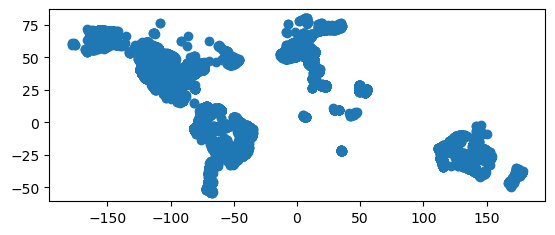

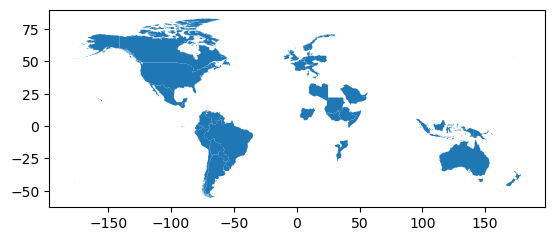

In [2]:
# look at each to enure it read in correctly
oil = gpd.read_parquet(oil_path)
print(oil.head())  
oil.plot()

# this file is reduced to just those countries within some distance of the oil and gas wells
country = gpd.read_parquet(countries_path)
print(country.head())  
country.plot()

# Open the .tif file using rasterio
with rasterio.open(ghs_pop_path) as src:
    # Print the metadata of the file to verify it is correctly located
    print(src.meta)

In [ ]:
# Plot the geometries on top of each other

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
oil.plot(ax=ax, color='blue', edgecolor='black', alpha=0.5)
country.plot(ax=ax, color='green', edgecolor='black', alpha=0.5)
plt.title("Geometry file + oil and gas points")
plt.show()

In [3]:
# Setting buffer dist to 1 km 
oil["buffer_dist"] = 1000 # buffer distance in in meters 


Reading data and finding best UTM projection for hazard geometries (1/6)


/Users/ninaflores/Documents/repos/ogd/code/function_optimized.py:42: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  ch_shp["centroid_lon"] = ch_shp.centroid.x
/Users/ninaflores/Documents/repos/ogd/code/function_optimized.py:43: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  ch_shp["centroid_lat"] = ch_shp.centroid.y


Reading spatial unit geometries (1/6)


Buffering hazard geometries (3/6): 100%|██████████| 4519663/4519663 [4:49:52<00:00, 259.87it/s]  
